In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('./genres_v2.csv')
df.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14984\3354925229.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./genres_v2.csv')


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,id,uri,track_href,analysis_url,duration_ms,time_signature,genre,song_name,Unnamed: 0,title
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.013400,0.0556,0.3890,...,2Vc6NJ9PW9gD9q343XFRKx,spotify:track:2Vc6NJ9PW9gD9q343XFRKx,https://api.spotify.com/v1/tracks/2Vc6NJ9PW9gD...,https://api.spotify.com/v1/audio-analysis/2Vc6...,124539,4,Dark Trap,Mercury: Retrograde,NaN,NaN
1,0.719,0.493,8,-7.230,1,0.0794,0.4010,0.000000,0.1180,0.1240,...,7pgJBLVz5VmnL7uGHmRj6p,spotify:track:7pgJBLVz5VmnL7uGHmRj6p,https://api.spotify.com/v1/tracks/7pgJBLVz5Vmn...,https://api.spotify.com/v1/audio-analysis/7pgJ...,224427,4,Dark Trap,Pathology,NaN,NaN
2,0.850,0.893,5,-4.783,1,0.0623,0.0138,0.000004,0.3720,0.0391,...,0vSWgAlfpye0WCGeNmuNhy,spotify:track:0vSWgAlfpye0WCGeNmuNhy,https://api.spotify.com/v1/tracks/0vSWgAlfpye0...,https://api.spotify.com/v1/audio-analysis/0vSW...,98821,4,Dark Trap,Symbiote,NaN,NaN
3,0.476,0.781,0,-4.710,1,0.1030,0.0237,0.000000,0.1140,0.1750,...,0VSXnJqQkwuH2ei1nOQ1nu,spotify:track:0VSXnJqQkwuH2ei1nOQ1nu,https://api.spotify.com/v1/tracks/0VSXnJqQkwuH...,https://api.spotify.com/v1/audio-analysis/0VSX...,123661,3,Dark Trap,ProductOfDrugs (Prod. The Virus and Antidote),NaN,NaN
4,0.798,0.624,2,-7.668,1,0.2930,0.2170,0.000000,0.1660,0.5910,...,4jCeguq9rMTlbMmPHuO7S3,spotify:track:4jCeguq9rMTlbMmPHuO7S3,https://api.spotify.com/v1/tracks/4jCeguq9rMTl...,https://api.spotify.com/v1/audio-analysis/4jCe...,123298,4,Dark Trap,Venom,NaN,NaN


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42305 entries, 0 to 42304
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      42305 non-null  float64
 1   energy            42305 non-null  float64
 2   key               42305 non-null  int64  
 3   loudness          42305 non-null  float64
 4   mode              42305 non-null  int64  
 5   speechiness       42305 non-null  float64
 6   acousticness      42305 non-null  float64
 7   instrumentalness  42305 non-null  float64
 8   liveness          42305 non-null  float64
 9   valence           42305 non-null  float64
 10  tempo             42305 non-null  float64
 11  type              42305 non-null  object 
 12  id                42305 non-null  object 
 13  uri               42305 non-null  object 
 14  track_href        42305 non-null  object 
 15  analysis_url      42305 non-null  object 
 16  duration_ms       42305 non-null  int64 

In [30]:
df = df.select_dtypes('float64')

In [31]:
df = df.dropna()

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20780 entries, 21525 to 42304
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      20780 non-null  float64
 1   energy            20780 non-null  float64
 2   loudness          20780 non-null  float64
 3   speechiness       20780 non-null  float64
 4   acousticness      20780 non-null  float64
 5   instrumentalness  20780 non-null  float64
 6   liveness          20780 non-null  float64
 7   valence           20780 non-null  float64
 8   tempo             20780 non-null  float64
 9   Unnamed: 0        20780 non-null  float64
dtypes: float64(10)
memory usage: 1.7 MB


In [33]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Estandarizar los datos
scaler = StandardScaler()
df = scaler.fit_transform(df)
df

array([[ 1.40177505,  0.676664  , -0.31927979, ...,  1.32372293,
        -0.98078572, -1.73225382],
       [ 1.38107139, -1.50644647, -1.26333168, ...,  0.2567618 ,
        -1.10806566, -1.73208859],
       [ 0.87038117,  0.91827307, -0.27132461, ...,  2.24223729,
        -1.17295348, -1.73192337],
       ...,
       [-1.6692675 , -0.43646347,  0.96885925, ..., -0.79164348,
         0.74302884,  1.73705516],
       [-0.86872607,  0.42642605,  0.38254596, ...,  0.89693848,
         0.42991633,  1.73722039],
       [-0.50986267,  0.63351953,  0.00275497, ..., -0.74525386,
         0.75019593,  1.73738562]])

In [34]:
import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=15,   # tamaño del vecindario
    min_dist=0.1,     # compresión de clusters
    n_components=2,   # para visualizar en 2D
    random_state=42
)

X_umap = reducer.fit_transform(df)

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


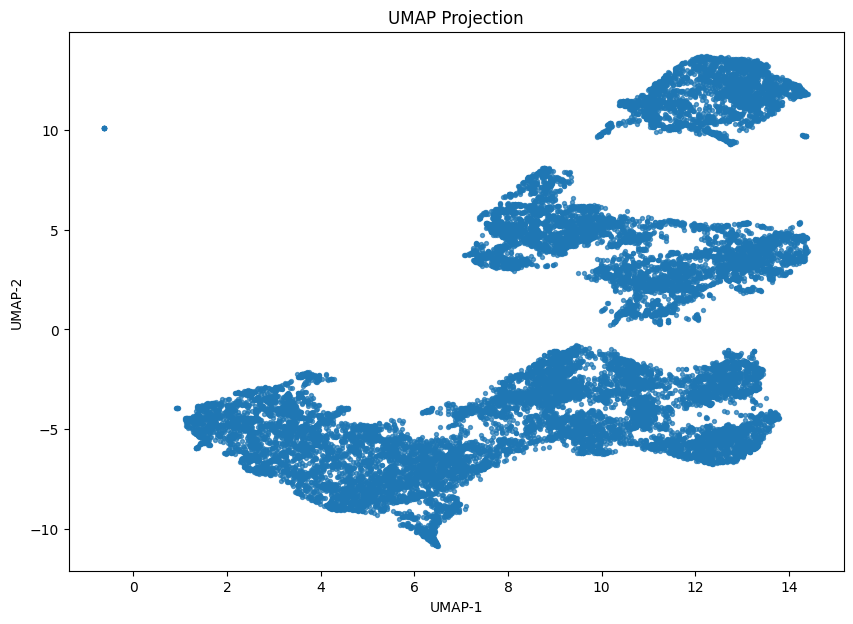

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=8, alpha=0.7)
plt.title("UMAP Projection")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

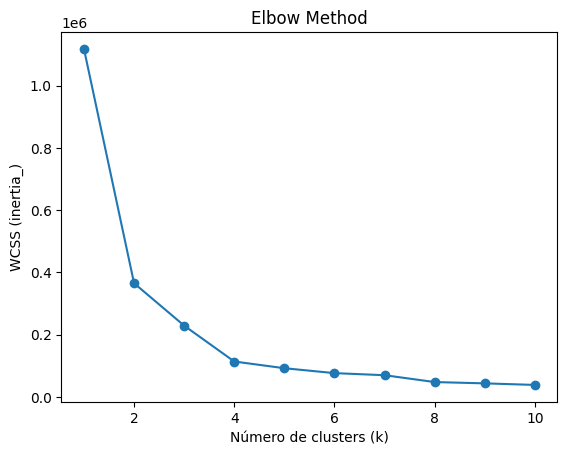

In [36]:
from sklearn.cluster import KMeans

wcss = []


for i in range(1, 11):
    model = KMeans(n_clusters=i)
    model.fit(X_umap)
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_umap)
    wcss.append(kmeans.inertia_)



plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Número de clusters (k)")
plt.ylabel("WCSS (inertia_)")
plt.show()

SSE: 113955.2421875
Silhouette Score: 0.5765234231948853


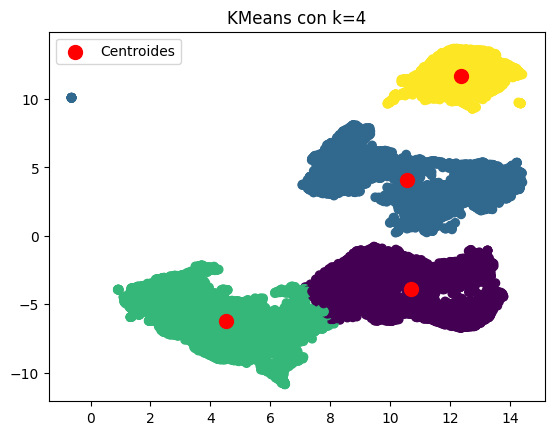

In [37]:
#se aprecian 4 grupos en el umap asi que k = 4 en el KMeans 

from sklearn.metrics import silhouette_score


k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_umap)

SSE = kmeans.inertia_
print("SSE:", SSE)


silhouette = silhouette_score(X_umap, labels)
print("Silhouette Score:", silhouette)


plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=100, c='red', marker='o', label='Centroides')
plt.title(f"KMeans con k={k}")
plt.legend()
plt.show()